In [65]:
readme_content = """
# ZEPTO DATA & AI PLATFORM
## Analytics Pipeline

This module performs exploratory data analysis, machine-learning classification,
class imbalance handling, hyperparameter tuning, and a regression side-task
using the Titanic dataset.

## 1. Module Structure

analytics/
├── 01_eda.ipynb
├── 02_modeling.ipynb
├── titanic.csv
├── model_pipeline.joblib
└── README.md

## 2. Installation

Install the required Python libraries:

pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn joblib

The notebooks can be executed using Google Colab or Jupyter Notebook.

## 3. Execution Order

01_eda.ipynb
    ↓
titanic.csv
    ↓
02_modeling.ipynb
    ↓
model_pipeline.joblib

## 4. 01_eda.ipynb

The EDA notebook:

- Loads the Titanic dataset.
- Examines dataset structure and data types.
- Identifies missing values.
- Removes the deck column because of high missingness.
- Imputes missing numerical and categorical values.
- Examines distributions and outliers.
- Analyzes survival rates.
- Examines correlations.
- Demonstrates numerical standardization.
- Saves the cleaned dataset as titanic.csv.

## 5. 02_modeling.ipynb

The modeling notebook:

- Loads titanic.csv.
- Separates features and target.
- Performs a stratified train/test split.
- Applies preprocessing through pipelines.
- Trains Logistic Regression.
- Trains Decision Tree.
- Trains Random Forest.
- Handles class imbalance using SMOTE.
- Performs Random Forest hyperparameter tuning using GridSearchCV.
- Evaluates classification models.
- Performs a fare-prediction regression task.
- Saves the final classification pipeline as model_pipeline.joblib.

## 6. Classification Models

The following models were evaluated:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Random Forest + SMOTE
5. Tuned Random Forest

Evaluation metrics:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Random Forest was also evaluated using out-of-bag scoring.

## 7. Classification Results

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Logistic Regression | 0.8045 | 0.7931 | 0.6667 | 0.7244 | 0.8439 |
| Decision Tree | 0.7654 | 0.7547 | 0.5797 | 0.6557 | 0.7971 |
| Random Forest | 0.8101 | 0.7778 | 0.7101 | 0.7424 | 0.8334 |
| Random Forest + SMOTE | 0.8101 | 0.7612 | 0.7391 | 0.7500 | 0.8415 |
| Tuned Random Forest | 0.7933 | 0.8200 | 0.5942 | 0.6891 | 0.8412 |

Random Forest OOB Score: 0.8020

Best GridSearchCV cross-validation ROC-AUC: 0.8780

## 8. Regression Side-Task

A Linear Regression model was used to predict passenger fare.

RMSE: 30.4731

R²: 0.3999

## 9. SMOTE

SMOTE was applied only to the training data through an imbalanced-learn
pipeline. The test set was kept unchanged.

Random Forest + SMOTE increased recall from 0.7101 to 0.7391 and F1-score
from 0.7424 to 0.7500 compared with the baseline Random Forest.

## 10. Hyperparameter Tuning

Random Forest hyperparameters were tuned using GridSearchCV with 5-fold
cross-validation and ROC-AUC as the scoring metric.

Best parameters:

max_depth = 5
min_samples_leaf = 1
min_samples_split = 2
n_estimators = 200

## 11. Saved Model

The final classification pipeline is saved as:

model_pipeline.joblib

The saved pipeline contains preprocessing, SMOTE, and the Random Forest
classifier.

The saved pipeline was reloaded and successfully tested on sample data.

## 12. Design Decisions

- A stratified train/test split was used to preserve target-class proportions.
- Numerical variables were standardized.
- Categorical variables were one-hot encoded.
- Preprocessing was placed inside pipelines.
- SMOTE was applied only to training data.
- Multiple classification metrics were used rather than accuracy alone.
- GridSearchCV was used for Random Forest hyperparameter tuning.
- The final saved model contains the complete preprocessing and classification
  pipeline.

## 13. Reproducibility

Random states were fixed where applicable.

Recommended execution order:

01_eda.ipynb
    ↓
titanic.csv
    ↓
02_modeling.ipynb
    ↓
model_pipeline.joblib
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme_content)

print("README.md created successfully!")

README.md created successfully!


# ZEPTO DATA & AI PLATFORM

## Module 2 — Analytics Pipeline
### Part B — Classification & Modeling

This notebook builds and evaluates machine-learning models for
Titanic survival prediction.

Pipeline:

Load Cleaned Dataset
→ Feature/Target Separation
→ Stratified Train/Test Split
→ Train-Only Preprocessing
→ Logistic Regression
→ Decision Tree
→ Random Forest
→ Class Imbalance Analysis
→ SMOTE
→ Random Forest Hyperparameter Tuning
→ Regression Side-Task
→ Final Model Comparison
→ Save Complete Pipeline

## 1. Import Libraries

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import (
    LogisticRegression,
    LinearRegression
)

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    mean_squared_error,
    r2_score
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import joblib

pd.set_option("display.max_columns", None)

## 2. Load the Cleaned Dataset

The modeling notebook does not reload the Titanic dataset from Seaborn.

It reads the cleaned `titanic.csv` generated by `01_eda.ipynb`.

In [40]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("titanic.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Saving titanic.csv to titanic (1).csv
Dataset loaded successfully.
Shape: (891, 14)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


## 3. Define Features and Target

The target variable is `survived`.

The target is kept separate from the predictor variables throughout
the modeling process.

In [ ]:
target = "survived"

features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

X = df[features]
y = df[target]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

## 4. Stratified Train/Test Split

The split is performed before preprocessing.

Stratification is used so that the proportion of survivors and
non-survivors remains approximately consistent in both datasets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

## 5. Preprocessing Pipeline

Numerical variables are standardized.

Categorical variables are one-hot encoded.

The preprocessing transformers are fitted only on the training data
through the sklearn Pipeline.

In [ ]:
numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

categorical_features = [
    "sex",
    "embarked"
]

numeric_transformer = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

## 6. Evaluation Function

We will use the same evaluation metrics for all three classifiers:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix

In [ ]:
def evaluate_classifier(model, X_test, y_test):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print("Accuracy:",
          round(accuracy_score(y_test, y_pred), 4))

    print("Precision:",
          round(precision_score(y_test, y_pred), 4))

    print("Recall:",
          round(recall_score(y_test, y_pred), 4))

    print("F1:",
          round(f1_score(y_test, y_pred), 4))

    print("ROC-AUC:",
          round(roc_auc_score(y_test, y_prob), 4))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

## 7. Logistic Regression

In [41]:
logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

logistic_pipeline.fit(
    X_train,
    y_train
)

print("Logistic Regression Results")
evaluate_classifier(
    logistic_pipeline,
    X_test,
    y_test
)

Logistic Regression Results
Accuracy: 0.8045
Precision: 0.7931
Recall: 0.6667
F1: 0.7244
ROC-AUC: 0.8439

Confusion Matrix:
[[98 12]
 [23 46]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



## 8. Decision Tree

In [42]:
decision_tree_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            DecisionTreeClassifier(
                random_state=42,
                max_depth=5
            )
        )
    ]
)

decision_tree_pipeline.fit(
    X_train,
    y_train
)

print("Decision Tree Results")
evaluate_classifier(
    decision_tree_pipeline,
    X_test,
    y_test
)

Decision Tree Results
Accuracy: 0.7654
Precision: 0.7547
Recall: 0.5797
F1: 0.6557
ROC-AUC: 0.7971

Confusion Matrix:
[[97 13]
 [29 40]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.88      0.82       110
           1       0.75      0.58      0.66        69

    accuracy                           0.77       179
   macro avg       0.76      0.73      0.74       179
weighted avg       0.76      0.77      0.76       179



## 9. Random Forest

In [43]:
random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                oob_score=True,
                n_jobs=-1
            )
        )
    ]
)

random_forest_pipeline.fit(
    X_train,
    y_train
)

print("Random Forest Results")

evaluate_classifier(
    random_forest_pipeline,
    X_test,
    y_test
)

print(
    "\nRandom Forest OOB Score:",
    round(
        random_forest_pipeline
        .named_steps["model"]
        .oob_score_,
        4
    )
)

Random Forest Results
Accuracy: 0.8101
Precision: 0.7778
Recall: 0.7101
F1: 0.7424
ROC-AUC: 0.8334

Confusion Matrix:
[[96 14]
 [20 49]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.71      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179


Random Forest OOB Score: 0.802


## 10. Compare the Three Classifiers

In [ ]:
models = {
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": decision_tree_pipeline,
    "Random Forest": random_forest_pipeline
}

results = []

for name, model in models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_test,
            y_pred
        ),
        "Precision": precision_score(
            y_test,
            y_pred
        ),
        "Recall": recall_score(
            y_test,
            y_pred
        ),
        "F1": f1_score(
            y_test,
            y_pred
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            y_prob
        )
    })

results_df = pd.DataFrame(results)

results_df.round(4)

## 11. Class Imbalance

In [ ]:
print("Training class distribution:")
print(y_train.value_counts())

plt.figure(figsize=(7, 5))

sns.countplot(
    x=y_train
)

plt.title("Training Set Class Distribution")
plt.xlabel("Survived")
plt.ylabel("Count")

plt.show()

### Applying SMOTE

SMOTE will be applied only to the training portion of the data.

The test set remains untouched so that it continues to represent
unseen data.

In [ ]:
smote_rf_pipeline = ImbPipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "smote",
            SMOTE(
                random_state=42
            )
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                oob_score=True,
                n_jobs=-1
            )
        )
    ]
)

smote_rf_pipeline.fit(
    X_train,
    y_train
)

In [44]:
print("Random Forest + SMOTE Results")

evaluate_classifier(
    smote_rf_pipeline,
    X_test,
    y_test
)

Random Forest + SMOTE Results
Accuracy: 0.8101
Precision: 0.7612
Recall: 0.7391
F1: 0.75
ROC-AUC: 0.8415

Confusion Matrix:
[[94 16]
 [18 51]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.85      0.85       110
           1       0.76      0.74      0.75        69

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [ ]:
y_pred_smote = smote_rf_pipeline.predict(X_test)
y_prob_smote = smote_rf_pipeline.predict_proba(X_test)[:, 1]

smote_results = {
    "Model": "Random Forest + SMOTE",
    "Accuracy": accuracy_score(
        y_test,
        y_pred_smote
    ),
    "Precision": precision_score(
        y_test,
        y_pred_smote
    ),
    "Recall": recall_score(
        y_test,
        y_pred_smote
    ),
    "F1": f1_score(
        y_test,
        y_pred_smote
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        y_prob_smote
    )
}

results_df = pd.concat(
    [
        results_df,
        pd.DataFrame([smote_results])
    ],
    ignore_index=True
)

results_df.round(4)

In [ ]:
results_df = results_df.drop_duplicates(
    subset=["Model"],
    keep="first"
).reset_index(drop=True)

results_df.round(4)

## 12. Random Forest Hyperparameter Tuning

GridSearchCV is used to search for a better Random Forest
configuration.

The search uses cross-validation and ROC-AUC as the scoring metric.

Out-of-bag scoring remains enabled for the Random Forest.

In [ ]:
rf_pipeline_for_tuning = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                random_state=42,
                oob_score=True,
                n_jobs=-1
            )
        )
    ]
)

In [53]:
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

In [54]:
grid_search = GridSearchCV(
    estimator=rf_pipeline_for_tuning,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    refit=True
)

grid_search.fit(
    X_train,
    y_train
)

print("Grid search completed.")

Grid search completed.


In [55]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(round(grid_search.best_score_, 4))

Best Parameters:
{'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Best Cross-Validation ROC-AUC:
0.878


In [56]:
print("Tuned Random Forest Results")

evaluate_classifier(
    grid_search.best_estimator_,
    X_test,
    y_test
)

Tuned Random Forest Results
Accuracy: 0.7933
Precision: 0.82
Recall: 0.5942
F1: 0.6891
ROC-AUC: 0.8412

Confusion Matrix:
[[101   9]
 [ 28  41]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.92      0.85       110
           1       0.82      0.59      0.69        69

    accuracy                           0.79       179
   macro avg       0.80      0.76      0.77       179
weighted avg       0.80      0.79      0.79       179



In [45]:
tuned_rf = grid_search.best_estimator_

print(
    "\nTuned Random Forest OOB Score:",
    round(
        tuned_rf
        .named_steps["model"]
        .oob_score_,
        4
    )
)


Tuned Random Forest OOB Score: 0.8301


## 13. Add Tuned Random Forest to Model Comparison

In [63]:
y_pred_tuned = tuned_rf.predict(X_test)
y_prob_tuned = tuned_rf.predict_proba(X_test)[:, 1]

tuned_results = {
    "Model": "Tuned Random Forest",
    "Accuracy": accuracy_score(
        y_test,
        y_pred_tuned
    ),
    "Precision": precision_score(
        y_test,
        y_pred_tuned
    ),
    "Recall": recall_score(
        y_test,
        y_pred_tuned
    ),
    "F1": f1_score(
        y_test,
        y_pred_tuned
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        y_prob_tuned
    )
}

results_df = pd.concat(
    [
        results_df,
        pd.DataFrame([tuned_results])
    ],
    ignore_index=True
)

results_df.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8045,0.7931,0.6667,0.7244,0.8439
1,Decision Tree,0.7654,0.7547,0.5797,0.6557,0.7971
2,Random Forest,0.8101,0.7778,0.7101,0.7424,0.8334
3,Random Forest + SMOTE,0.8101,0.7612,0.7391,0.7500,0.8415
4,Tuned Random Forest,0.7933,0.8200,0.5942,0.6891,0.8412


## 14. Regression Side-Task

A Linear Regression model is used to predict passenger fare.

The target variable for this side-task is `fare`.

In [46]:
regression_features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "embarked"
]

X_reg = df[regression_features]
y_reg = df["fare"]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("Regression training shape:", X_reg_train.shape)
print("Regression test shape:", X_reg_test.shape)

Regression training shape: (712, 6)
Regression test shape: (179, 6)


In [47]:
reg_numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch"
]

reg_categorical_features = [
    "sex",
    "embarked"
]

reg_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            reg_numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            reg_categorical_features
        )
    ]
)

In [48]:
regression_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            reg_preprocessor
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)

regression_pipeline.fit(
    X_reg_train,
    y_reg_train
)

y_reg_pred = regression_pipeline.predict(
    X_reg_test
)

In [57]:
rmse = np.sqrt(
    mean_squared_error(
        y_reg_test,
        y_reg_pred
    )
)

r2 = r2_score(
    y_reg_test,
    y_reg_pred
)

print("Regression RMSE:", round(rmse, 4))
print("Regression R²:", round(r2, 4))

Regression RMSE: 30.4731
Regression R²: 0.3999


## 15. Final Classification Model Comparison

All classification models are evaluated on the same held-out test
set using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

The comparison also considers the effect of SMOTE and the tuned
Random Forest configuration.

In [58]:
results_df = (
    results_df
    .drop_duplicates(subset=["Model"])
    .reset_index(drop=True)
)

results_df.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8045,0.7931,0.6667,0.7244,0.8439
1,Decision Tree,0.7654,0.7547,0.5797,0.6557,0.7971
2,Random Forest,0.8101,0.7778,0.7101,0.7424,0.8334
3,Random Forest + SMOTE,0.8101,0.7612,0.7391,0.7500,0.8415


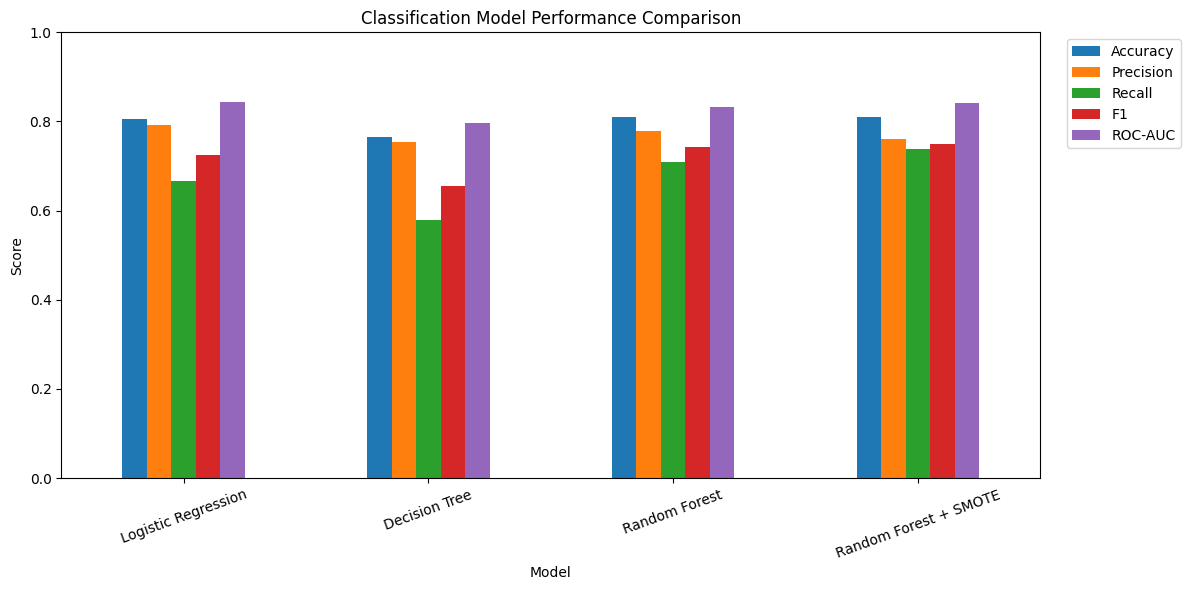

In [51]:
results_plot = results_df.set_index("Model")[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ]
]

results_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Classification Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=20)
plt.ylim(0, 1)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## 16. Model Comparison and Final Model Selection

Five classification configurations were evaluated using the same
held-out test set.

The untuned Random Forest achieved an accuracy of 0.8101, while the
Random Forest with SMOTE also achieved 0.8101 accuracy.

SMOTE increased recall from 0.7101 to 0.7391 and F1-score from
0.7424 to 0.7500, while precision decreased from 0.7778 to 0.7612.

The tuned Random Forest achieved a cross-validation ROC-AUC of 0.8780,
but its held-out test ROC-AUC was 0.8412, with an F1-score of 0.6891.

Based on the held-out test results, Random Forest with SMOTE provides
the highest recall and F1-score among the evaluated models. Therefore,
the Random Forest + SMOTE pipeline is retained as the final
classification pipeline for this project.

The regression side-task produced an RMSE of 30.4731 and an R² of
0.3999 for fare prediction.

## 17. Save the Final Model Pipeline

The final pipeline contains:

1. Numerical preprocessing
2. Categorical preprocessing
3. SMOTE
4. Random Forest classifier

Saving the complete pipeline allows the same preprocessing steps to
be automatically applied when new data is passed to the model.

In [59]:
final_model = smote_rf_pipeline

joblib.dump(
    final_model,
    "model_pipeline.joblib"
)

print("Final model pipeline saved successfully.")

Final model pipeline saved successfully.


In [60]:
import os

print(
    "File exists:",
    os.path.exists("model_pipeline.joblib")
)

print(
    "File size:",
    round(
        os.path.getsize("model_pipeline.joblib") / 1024,
        2
    ),
    "KB"
)

File exists: True
File size: 5392.86 KB


In [61]:
loaded_model = joblib.load(
    "model_pipeline.joblib"
)

print("Model loaded successfully.")
print(loaded_model)

Model loaded successfully.
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['sex', 'embarked'])])),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
           

In [ ]:
sample_data = X_test.head(5)

sample_predictions = loaded_model.predict(
    sample_data
)

print("Sample predictions:")
print(sample_predictions)

## 18. Final Model Verification

The final pipeline was successfully saved and reloaded.

The pipeline contains the preprocessing transformations and the
Random Forest classifier. Predictions can therefore be generated
directly from the original feature representation without manually
repeating preprocessing steps.

In [64]:
print("========== FINAL PROJECT SUMMARY ==========")

print("\nClassification Results:")
display(results_df.round(4))

print("\nRegression Results:")
print("RMSE:", round(rmse, 4))
print("R²:", round(r2, 4))

print("\nFinal Pipeline:")
print("Random Forest + SMOTE")

print("\nSaved File:")
print("model_pipeline.joblib")

========== FINAL PROJECT SUMMARY ==========

Classification Results:


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8045,0.7931,0.6667,0.7244,0.8439
1,Decision Tree,0.7654,0.7547,0.5797,0.6557,0.7971
2,Random Forest,0.8101,0.7778,0.7101,0.7424,0.8334
3,Random Forest + SMOTE,0.8101,0.7612,0.7391,0.7500,0.8415
4,Tuned Random Forest,0.7933,0.8200,0.5942,0.6891,0.8412



Regression Results:
RMSE: 30.4731
R²: 0.3999

Final Pipeline:
Random Forest + SMOTE

Saved File:
model_pipeline.joblib
